# Simulación de Nanofluidos con MXene en geometría L — **Entrega Final**

**Reproducción y extensión del modelo de:**
Pineda, F. *et al.* (2025). *MXene-enhanced nanofluids for superior thermal energy storage in concentrated solar power plants*. **Solar Energy Materials and Solar Cells, 283**, 113461. [doi:10.1016/j.solmat.2025.113461](https://doi.org/10.1016/j.solmat.2025.113461)

**Estudiante:** Millaray Antonia Lagos Leiva  
**Asignatura:** Física computacional (Fis-205)

---

Este cuaderno reúne, de forma autocontenida, **dos simulaciones del autómata celular** sobre la geometría de MXene en forma de **L**:

1. **Simulación 1 — temperatura constante:** se observa la cinética de descomposición (decaimiento del reactante) a una temperatura reducida fija y el efecto estabilizador del MXene.
2. **Simulación 2 — temperatura variable:** sobre el mismo sistema se aplica una **rampa térmica** (la temperatura sube gradualmente) para ver cómo se acelera la descomposición, reproduciendo el protocolo de la sección 2.3.3 del paper.


## 1. Marco teórico — ¿Qué simulamos y por qué?

### 1.1 El problema físico

Las plantas de **Energía Solar Concentrada (CSP)** almacenan calor en *sales solares*
fundidas (60 wt-% NaNO₃ + 40 wt-% KNO₃). Subir la temperatura de operación mejora la
eficiencia del ciclo termodinámico, pero la sal se *descompone* químicamente cerca de
los 586 °C, liberando gases nitrosos (NOₓ).

El paper propone añadir **MXene multicapa (Ti₃C₂Tₓ)** —un material 2D— como aditivo
para:
- Aumentar la temperatura de descomposición $T_d$ (medida: 609.8 °C con 3 wt-% de MXene vs 586.2 °C de la sal pura).
- Mejorar la capacidad calorífica específica $C_p$.

### 1.2 La hipótesis que el modelo computacional pone a prueba

| Efecto | Mecanismo en el modelo |
|---|---|
| **Topológico** | Los bloques de MXene ocupan espacio en la grilla y reducen la concentración local de reactantes vecinos. |
| **Energético** | La presencia de MXene aumenta la barrera de activación de la reacción (factor de Boltzmann menor). |

### 1.3 Especificaciones del modelo (paper):

- Grilla 50 × 50 con **condiciones de borde periódicas** (PBC).
- $N_A(0) = N_B(0) = 1000$ unidades de reactantes A y B.
- **Vecindad de Moore** (8 vecinos).
- MXenes representados como bloques $5\times 1$ con orientación aleatoria.
- Reacción directa $A+B \to C+D$ con probabilidad máxima $1/8$ a $T=1$.
- Reacción inversa $C+D \to A+B$ con probabilidad constante $10^{-4}$.
- Producto $D$ es un gas: tiende a *moverse hacia arriba* y escapa del sistema.

### 1.4 La variación de la geometria "L" (proyecto):

En lugar del bloque 5×1 lineal se implementa una **L de 5 celdas**:

```
   X . .          (5 celdas, mismo número que el bloque 5×1 del paper)
   X . .
   X X X
```

3 celdas verticales + 3 celdas horizontales − 1 esquina compartida = **5 celdas**.
Cuatro orientaciones equivalentes a las `up/down/right/left` del paper.


## 2. Imports y configuración

Implementamos los imports, con el parche de `Self`.

In [2]:
from __future__ import annotations
from typing import Any
try:
    from typing import Self          # Python ≥ 3.11
except ImportError:                  
    Self = "Nodes"

from math import exp
import random
import pickle
import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# Reproducibilidad (para verficiar fallas y resultados)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports OK")


Imports OK


In [3]:
# Animacion interactiva
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams["animation.embed_limit"] = 60  # MB
print("Animacion inline lista")

Animacion inline lista


## 3. Funciones auxiliares

### 3.1 `mef` — *manejo de errores formal*
Atajo para lanzar `RuntimeError` con un mensaje contextualizado.

### 3.2 `fn_reac` — la **probabilidad de reacción**

$$
p_{\text{reac}}(T) = 0.15 \cdot \exp\!\left(-\frac{E_a}{T}\right)
$$

donde la "energía de activación" $E_a$ toma dos valores según el contexto:

- $E_a = 0.2$ si la celda está **libre** de MXene (`is_free=True`).
- $E_a = 2.0$ si está **cerca de un MXene** (`is_free=False`).

El segundo caso modela el *efecto energético* del MXene: necesita ~10× más temperatura
para activarse.

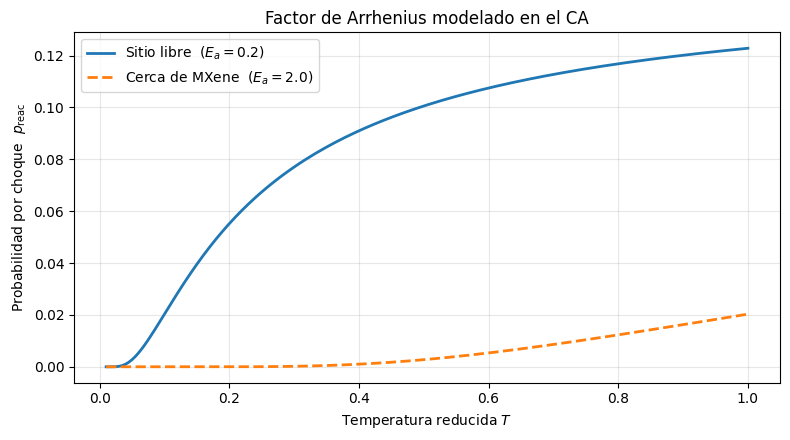

In [4]:
def mef(origen: str, mensaje: str) -> None:
    """Levanta un RuntimeError contextualizado y detiene el programa."""
    raise RuntimeError(f"¡ERROR! {origen} -> {mensaje}")


def fn_reac(t: float, is_free: bool = True) -> float:
    """Probabilidad de reacción A + B -> C + D en función de la temperatura T."""
    return 0.15 * exp(-0.2 / t) if is_free else 0.15 * exp(-2.0 / t)


# Visualicemos rápidamente cómo se comporta fn_reac
ts = np.linspace(0.01, 1.0, 200)
p_libre = [fn_reac(t, is_free=True)  for t in ts]
p_mxene = [fn_reac(t, is_free=False) for t in ts]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ts, p_libre, label="Sitio libre  ($E_a = 0.2$)", lw=2)
ax.plot(ts, p_mxene, label="Cerca de MXene  ($E_a = 2.0$)", lw=2, linestyle="--")
ax.set_xlabel("Temperatura reducida $T$")
ax.set_ylabel("Probabilidad por choque  $p_\\mathrm{reac}$")
ax.set_title("Factor de Arrhenius modelado en el CA")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Ingeniería inversa de la clase `Nodes`

### 4.1 Idea general

Cada **celda** de la grilla 50×50 es un objeto `Nodes`. La clase combina:

- **Atributos de instancia**: el estado químico de la celda, su posición, sus vecinos, banderas
  de movimiento/reacción.
- **Atributos de clase** (compartidos): la lista global `instances`, un diccionario
  `pos_to_id` que traduce coordenadas → índice, y un `banco` que se serializa con pickle.

### 4.2 Estados (`state`)

| Estado | Significado | Color |
|---|---|---|
| 0 | Vacío | gris |
| 1 | Reactante A | rojo |
| 2 | Reactante B | azul |
| 3 | Producto C | verde |
| 4 | Producto D (**gas** — sube y escapa) | violeta |
| 5 | MXene (**fijo**, no se mueve ni reacciona) | naranjo |

### 5.3 El bucle de simulación (lo que pasa en *cada paso*)

**Si `tipo == "mueve"`:**
1. Se calcula `prob_moverse = 0.5 * fn_reac(T)`.
2. Se mezclan todos los nodos móviles en orden aleatorio (Monte Carlo asincrónico).
3. Para cada nodo no movido:
   - Tirada $u \sim \mathcal{U}(0,1)$; si $u \geq p$, se queda quieto.
   - Filtra vecinos válidos (móviles, no movidos, no estado 4).
   - **Si el nodo es estado 4 (gas D)**: restringe a vecinos con `fila ≤ fila_actual`
     → el gas **tiende a subir** (clave para entender el "escape" del producto).
   - Intercambia su `state` con el de un vecino elegido al azar.

**Si `tipo == "reacciona"`:** estructura `match-case` por `state`:
- Estado 1 busca vecinos en estado 2 (reacción $A + B \to C + D$).
- Estado 2 busca estado 1 (simétrico).
- Estado 3 busca estado 4 (reacción inversa, $p_{base} = 10^{-4}$).
- Estado 4 busca estado 3 (simétrico de la inversa).
- La probabilidad efectiva es $p_{base} \cdot \mathrm{fn\_reac}(T, \text{is\_free})$
  multiplicada por el número de vecinos compatibles.


## 5. Implementación de la clase `Nodes`

1. `from typing import Self` añadido.
2. Las constantes de tamaño se reciben por parámetro.
3. Método `reset_class` añadido para reusar la misma instancia entre simulaciones.

In [5]:
class Nodes:
    instances: list[Self] = []
    pos_to_id: dict[tuple[int, int], int] = {}
    banco: list[Any] = [{}, []]
    NF_LY: int = 50
    NC_LX: int = 50

    def __init__(self, pos: tuple[int, int], hm: bool = True, ir: bool = True) -> None:
        self.id: int = len(Nodes.instances)
        self.state: int = 0
        self.new_state: int | None = None
        self.has_mobility: bool = hm
        self.has_moved: bool = False
        self.is_reactive: bool = ir
        self.has_reacted: bool = False
        self.coord: tuple[int, int] = pos
        self.links: list[int] = []
        Nodes.instances.append(self)
        Nodes.pos_to_id[self.coord] = self.id

    def set_fixed(self) -> None:
        self.has_mobility = False
        self.is_reactive = False

    @classmethod
    def all(cls) -> int:
        return len(cls.instances)

    @classmethod
    def reset_class(cls) -> None:
        """Limpia el estado de clase entre simulaciones."""
        cls.instances = []
        cls.pos_to_id = {}
        cls.banco = [{}, []]

    @classmethod
    def reset_flag_movement(cls) -> None:
        for ins in cls.instances:
            ins.has_moved = False

    @classmethod
    def reset_flag_reaction(cls) -> None:
        for ins in cls.instances:
            ins.has_reacted = False

    @classmethod
    def connect(cls, vecindad: str) -> None:
        NF_LY, NC_LX = cls.NF_LY, cls.NC_LX
        for ins in cls.instances:
            f, c = ins.coord
            if vecindad == "von_Neumann":
                deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]
            elif vecindad == "Moore":
                deltas = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                          (1, 0),  (1, -1), (0, -1), (-1, -1)]
            else:
                mef("Nodes.connect", "Vecindad incorrecta")
            for df, dc in deltas:
                nf = cls.pbc(f + df, NF_LY)
                nc = cls.pbc(c + dc, NC_LX)
                ins.links.append(cls.pos_to_id[(nf, nc)])

    @classmethod
    def nuevo_estado(cls, tipo: str, temperature: float) -> None:
        if tipo == "mueve":
            p_mov = 0.5 * fn_reac(temperature)
            cls.reset_flag_movement()
            scrambled = [ins for ins in cls.instances if ins.has_mobility]
            random.shuffle(scrambled)
            for ins in scrambled:
                if ins.has_moved:
                    continue
                ins.has_moved = True
                if not random.random() < p_mov:
                    continue
                pre = [cls.instances[il] for il in ins.links
                       if cls.instances[il].has_mobility
                       and not cls.instances[il].has_moved
                       and cls.instances[il].state != 4]
                if ins.state == 4:
                    # El gas D tiende a subir: solo puede ir a vecinos arriba o iguales
                    posibles = [p for p in pre if p.coord[0] <= ins.coord[0]]
                else:
                    posibles = pre
                if posibles:
                    otro = random.choice(posibles)
                    ins.state, otro.state = otro.state, ins.state
                    otro.has_moved = True

        elif tipo == "reacciona":
            p_fwd = 1.0
            p_rev = 1e-4
            cls.reset_flag_reaction()
            scrambled = [ins for ins in cls.instances if ins.is_reactive]
            random.shuffle(scrambled)

            for ins in scrambled:
                if ins.has_reacted:
                    continue
                near_mxene = any(cls.instances[il].state == 5 for il in ins.links)
                is_free = not near_mxene

                match ins.state:
                    case 1:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 2
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 3, 4
                        p_base = p_fwd
                    case 2:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 1
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 4, 3
                        p_base = p_fwd
                    case 3:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 4
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 1, 2
                        p_base = p_rev
                    case 4:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 3
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 2, 1
                        p_base = p_rev
                    case _:
                        continue

                if not partners:
                    continue
                p = p_base * fn_reac(temperature, is_free)
                if random.random() < len(partners) * p:
                    other = random.choice(partners)
                    ins.state = new_self
                    other.state = new_other
                    ins.has_reacted = True
                    other.has_reacted = True

    @classmethod
    def agrega_banco(cls, donde: Any, que: Any) -> None:
        if isinstance(donde, str) and donde.upper() == "A":
            cls.banco.append(que)
        elif isinstance(donde, int) and donde in (0, 1):
            cls.banco[donde] = que.copy()
        else:
            mef("agrega_banco", "Índice incorrecto")

    @classmethod
    def escribe(cls, ruta: str = "banco.pkl") -> None:
        with open(ruta, "wb") as f:
            pickle.dump(cls.banco, f, -1)

    @staticmethod
    def pbc(ind: int, el_max: int) -> int:
        return ind % el_max

print("Clase Nodes lista")


Clase Nodes lista


## 6. Geometría L 

En lugar de las cuatro orientaciones `up/down/right/left` del paper que generan
bloques 5×1 lineales, definimos cuatro orientaciones de L (una por cada rotación
de 90°). Cada L son **5 celdas**, igual que el 5×1 del paper, así que la
**masa total de MXene se conserva**.

### Las 4 orientaciones

```
   "L_dr"          "L_dl"        "L_ur"        "L_ul"
   X . .           . . X         X X X         X X X
   X . .           . . X         X . .         . . X
   X X X           X X X         X . .         . . X
```

(`dr` = corner abajo-derecha, `dl` = abajo-izquierda, `ur` = arriba-derecha,
`ul` = arriba-izquierda)

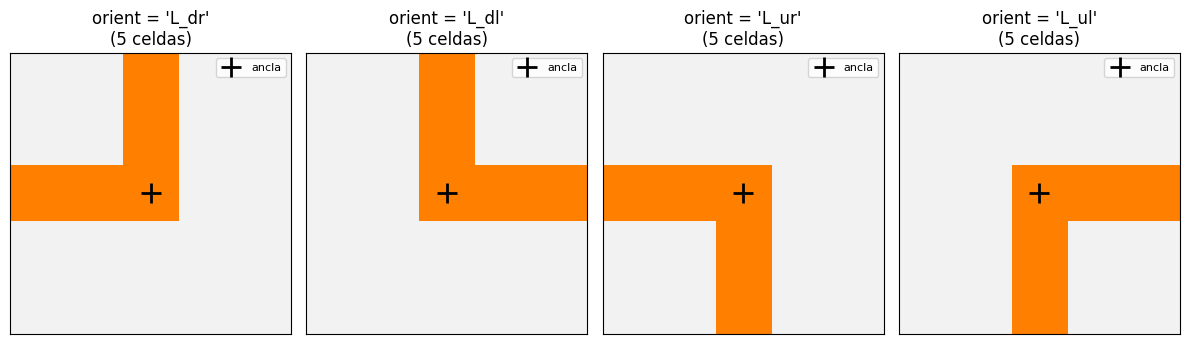

Las 4 orientaciones de la L — todas con 5 celdas, esquina marcada con +


In [6]:
def coords_L(xm0: int, ym0: int, orient: str) -> list[tuple[int, int]]:
    """Devuelve las 5 celdas de una L en una de sus 4 rotaciones."""
    match orient:
        case "L_dr":   # esquina abajo-derecha: brazo arriba y a la izquierda
            return [(xm0, ym0),
                    (xm0 - 1, ym0), (xm0 - 2, ym0),
                    (xm0, ym0 - 1), (xm0, ym0 - 2)]
        case "L_dl":   # esquina abajo-izquierda: brazo arriba y a la derecha
            return [(xm0, ym0),
                    (xm0 - 1, ym0), (xm0 - 2, ym0),
                    (xm0, ym0 + 1), (xm0, ym0 + 2)]
        case "L_ur":   # esquina arriba-derecha: brazo abajo y a la izquierda
            return [(xm0, ym0),
                    (xm0 + 1, ym0), (xm0 + 2, ym0),
                    (xm0, ym0 - 1), (xm0, ym0 - 2)]
        case "L_ul":   # esquina arriba-izquierda: brazo abajo y a la derecha
            return [(xm0, ym0),
                    (xm0 + 1, ym0), (xm0 + 2, ym0),
                    (xm0, ym0 + 1), (xm0, ym0 + 2)]
        case _:
            mef("coords_L", f"Orientación desconocida: {orient}")


# Verificación visual de las 4 orientaciones
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, orient in zip(axes, ["L_dr", "L_dl", "L_ur", "L_ul"]):
    M = np.zeros((5, 5))
    for f, c in coords_L(2, 2, orient):
        M[f, c] = 5
    ax.imshow(M, cmap=ListedColormap(["#f2f2f2", "#ff7f00"]),
              vmin=0, vmax=5)
    ax.plot(2, 2, "k+", markersize=15, markeredgewidth=2, label="ancla")
    ax.set_title(f"orient = '{orient}'\n(5 celdas)")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()
print("Las 4 orientaciones de la L — todas con 5 celdas, esquina marcada con +")


## 7. Inicialización de la grilla

Recreamos el setup del paper: 50×50 con PBC, vecindad de Moore, 1000 unidades
de A y B, 100 bloques de MXene. Mantenemos también una versión **sin MXene** y
una con bloques **5×1 del paper** como referencias.

In [7]:
def coords_5x1(xm0, ym0, orient):
    """Bloque 5×1 original del paper — para comparar."""
    match orient:
        case "up":    return [(xm0, ym0 - k) for k in range(5)]
        case "down":  return [(xm0, ym0 + k) for k in range(5)]
        case "right": return [(xm0 + k, ym0) for k in range(5)]
        case "left":  return [(xm0 - k, ym0) for k in range(5)]


# Diccionario: nombre → (función generadora, orientaciones, margen, celdas/bloque)
SHAPES = {
    "5x1 (paper)": (coords_5x1, ["up", "down", "right", "left"], 4, 5),
    "L":           (coords_L,   ["L_dr", "L_dl", "L_ur", "L_ul"], 3, 5),
}


def build_grid(NF_LY: int = 50,
               NC_LX: int = 50,
               n_A: int = 1000,
               n_B: int = 1000,
               shape: str | None = None,
               num_mxene: int = 100,
               vecindad: str = "Moore",
               seed: int | None = 42,
               verbose: bool = True) -> None:
    """Construye una grilla limpia con reactantes y (opcionalmente) MXenes.

    Parameters
    ----------
    shape : str | None
        Nombre de la geometría: "5x1 (paper)", "L", o None (sin MXene).
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    Nodes.reset_class()
    Nodes.NF_LY = NF_LY
    Nodes.NC_LX = NC_LX

    # 1) Crear celdas vacías
    for f in range(NF_LY):
        for c in range(NC_LX):
            Nodes((f, c))

    # 2) Conectar topología
    Nodes.connect(vecindad)

    # 3) Metadatos
    Nodes.agrega_banco(0, {
        "NF_LY": NF_LY, "NC_LX": NC_LX,
        "width_tile": 20, "height_tile": 20, "margin_tile": 3,
    })

    # 4) Sembrar MXenes (si shape is not None)
    if shape is not None:
        coords_fn, orientaciones, margen, celdas_por_bloque = SHAPES[shape]
        sembrados, intentos = 0, 0
        max_intentos = num_mxene * 200
        while sembrados < num_mxene and intentos < max_intentos:
            intentos += 1
            xm0 = random.choice(range(margen, NF_LY - margen))
            ym0 = random.choice(range(margen, NC_LX - margen))
            orient = random.choice(orientaciones)
            candidatas = coords_fn(xm0, ym0, orient)
            # CAMBIO CLAVE vs paper: verificar TODAS las celdas, no solo el ancla
            if not all(Nodes.instances[Nodes.pos_to_id[c]].state == 0
                       for c in candidatas):
                continue
            for tc in candidatas:
                node = Nodes.instances[Nodes.pos_to_id[tc]]
                node.state = 5
                node.set_fixed()
            sembrados += 1
        if verbose:
            print(f"  → {shape}: {sembrados}/{num_mxene} bloques sembrados "
                  f"({sembrados * celdas_por_bloque} celdas, {intentos} intentos)")

    # 5) Sembrar reactantes — random.sample evita bucles infinitos
    indices_vacios = [i for i, n in enumerate(Nodes.instances) if n.state == 0]
    if n_A + n_B > len(indices_vacios):
        raise RuntimeError(f"No caben {n_A + n_B} reactantes en {len(indices_vacios)} huecos")
    elegidos = random.sample(indices_vacios, n_A + n_B)
    for i, idx in enumerate(elegidos):
        Nodes.instances[idx].state = 1 if i < n_A else 2

    # 6) Snapshot inicial
    Nodes.agrega_banco(1, [
        (Nodes.instances[i].coord, Nodes.instances[i].state)
        for i in range(Nodes.all())
    ])


def grid_to_array() -> np.ndarray:
    """Vuelca el estado actual de la grilla a una matriz NumPy."""
    M = np.zeros((Nodes.NF_LY, Nodes.NC_LX), dtype=int)
    for n in Nodes.instances:
        f, c = n.coord
        M[f, c] = n.state
    return M


def count_species(M: np.ndarray) -> dict[int, int]:
    return {s: int((M == s).sum()) for s in range(6)}


# Construimos los TRES sistemas que compararemos
print("Construyendo sistemas:")
print("\n[Sin MXene]")
build_grid(shape=None, seed=SEED)
grid_pure = grid_to_array()

print("\n[5×1 (paper)]")
build_grid(shape="5x1 (paper)", seed=SEED)
grid_5x1 = grid_to_array()

print("\n[L]")
build_grid(shape="L", seed=SEED)
grid_L = grid_to_array()

print("\nResumen:")
for nombre, M in [("Sin MXene", grid_pure), ("5×1", grid_5x1), ("L", grid_L)]:
    c = count_species(M)
    print(f"  {nombre:<12}  A={c[1]}, B={c[2]}, MXene={c[5]}")


Construyendo sistemas:

[Sin MXene]

[5×1 (paper)]
  → 5x1 (paper): 100/100 bloques sembrados (500 celdas, 166 intentos)

[L]
  → L: 100/100 bloques sembrados (500 celdas, 169 intentos)

Resumen:
  Sin MXene     A=1000, B=1000, MXene=0
  5×1           A=1000, B=1000, MXene=500
  L             A=1000, B=1000, MXene=500


## 8. Visualización — malla inicial de las 3 configuraciones


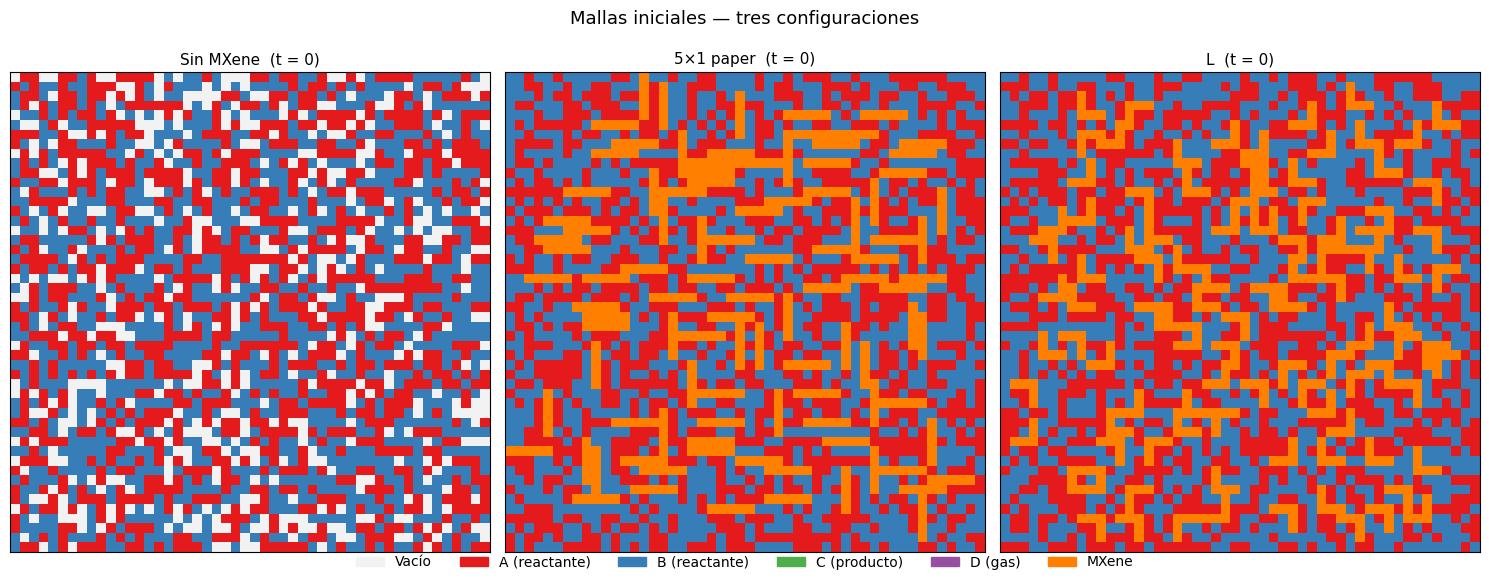

In [8]:
COLORES = ["#f2f2f2", "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
ETIQUETAS = ["Vacío", "A (reactante)", "B (reactante)",
             "C (producto)", "D (gas)", "MXene"]
CMAP = ListedColormap(COLORES)
NORM = BoundaryNorm(np.arange(-0.5, len(COLORES) + 0.5, 1), CMAP.N)


def plot_malla(matriz, titulo, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(matriz, cmap=CMAP, norm=NORM, interpolation="nearest")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])


# Vista panorámica de las 3 configuraciones
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
plot_malla(grid_pure, "Sin MXene  (t = 0)",     ax=axes[0])
plot_malla(grid_5x1,  "5×1 paper  (t = 0)",     ax=axes[1])
plot_malla(grid_L,    "L  (t = 0)",             ax=axes[2])

handles = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORES, ETIQUETAS)]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mallas iniciales — tres configuraciones", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# Simulación 1 — Temperatura constante

En esta primera simulación la temperatura reducida se mantiene **fija** en $T = 0.15$. Corresponde a la primera parte del protocolo del paper: *medir la evolución del sistema a temperatura constante*. Observamos tres cosas: (1) la evolución espacial de la grilla, (2) la **curva de decaimiento** del reactante A a lo largo de 50 iteraciones y (3) la comparación entre la configuración en **L**, el bloque **5×1** del paper y el control **sin MXene**.

Recordatorio físico: cada iteración del autómata es la unidad de *tiempo* reducido (un barrido de movimiento + uno de reacción), y a $T$ constante la probabilidad de reacción por choque también es constante.

In [9]:
# --- Motores de corrida a temperatura fija (estructura del avance) ---
def run_and_snapshot(n_iter: int, temperature: float) -> list[np.ndarray]:
    snapshots = [grid_to_array()]
    for _ in range(n_iter):
        Nodes.nuevo_estado("mueve", temperature)
        Nodes.nuevo_estado("reacciona", temperature)
        snapshots.append(grid_to_array())
    return snapshots


def run_track(n_iter: int, temperature: float) -> list[dict]:
    historial = [count_species(grid_to_array())]
    for _ in range(n_iter):
        Nodes.nuevo_estado("mueve", temperature)
        Nodes.nuevo_estado("reacciona", temperature)
        historial.append(count_species(grid_to_array()))
    return historial


# Temperatura reducida CONSTANTE de la Simulacion 1
T_CONST = 0.15
N_ITER_CONST = 50          # la curva de decaimiento se limita a 50 iteraciones
print(f"T constante = {T_CONST} | {N_ITER_CONST} iteraciones")

T constante = 0.15 | 50 iteraciones


## 1.1 Evolución espacial del sistema

La animación muestra la configuración **L** evolucionando a temperatura constante: los reactantes A (rojo) y B (azul) se transforman en producto C (verde) y gas D (púrpura), mientras los bloques de MXene (naranja) permanecen **fijos** —son una estructura rígida del modelo—. Debajo se añade un montaje estático de fotogramas, cómodo para el informe en PDF.

In [10]:
# Animacion de la configuracion L evolucionando a temperatura constante
N_ANIM = 50
build_grid(shape="L", seed=SEED, verbose=False)
snaps_anim = run_and_snapshot(N_ANIM, T_CONST)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(snaps_anim[0], cmap=CMAP, norm=NORM, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
titulo = ax.set_title(f"L  -  T = {T_CONST}  -  Iteración 0 / {N_ANIM}")

def _update(k):
    im.set_data(snaps_anim[k])
    titulo.set_text(f"L  -  T = {T_CONST}  -  Iteración {k} / {N_ANIM}")
    return [im, titulo]

anim = FuncAnimation(fig, _update, frames=len(snaps_anim), interval=180, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

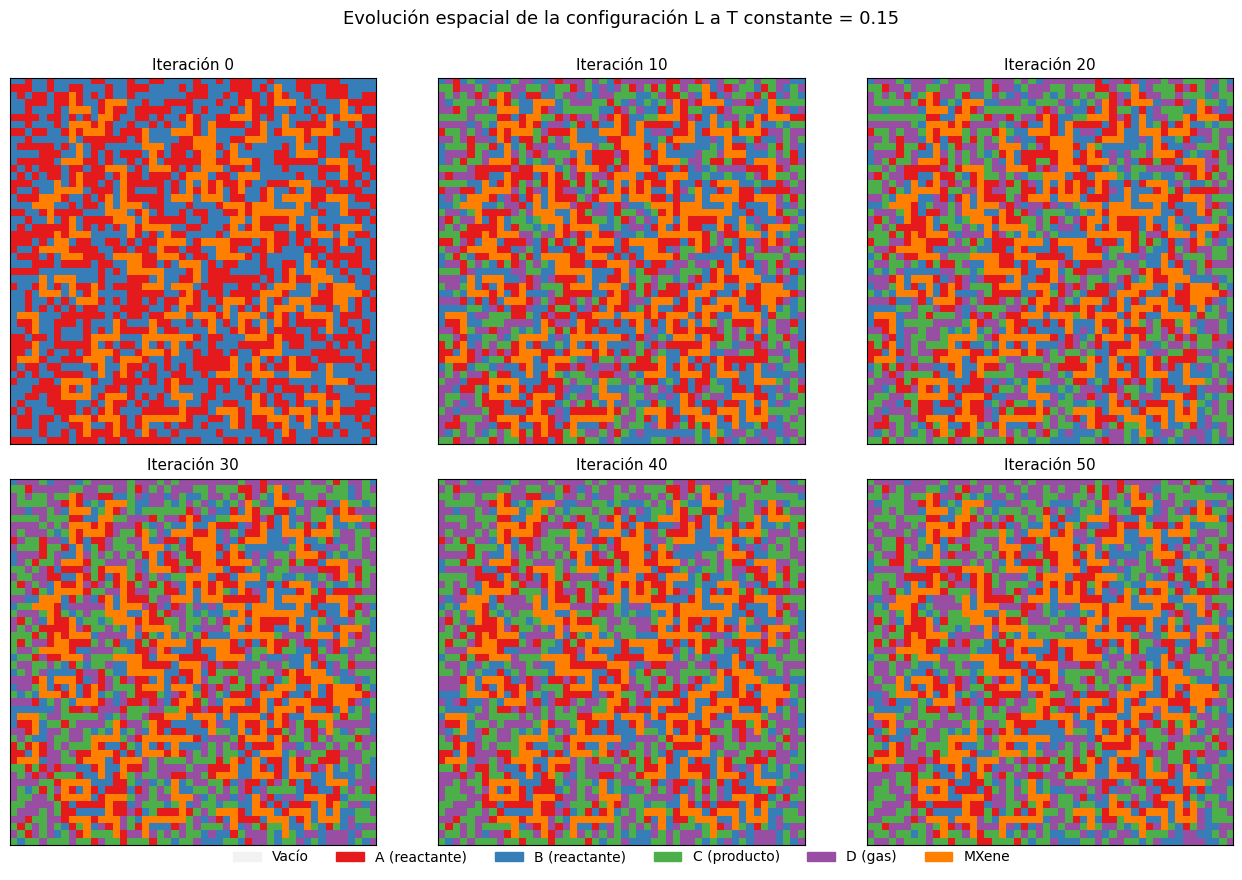

In [19]:
# Montaje estatico de fotogramas (PARA EL INFORME) NO PUEDO PONER VIDEOS EN EL INFORME ;(
idx = np.linspace(0, len(snaps_anim) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, k in zip(axes.ravel(), idx):
    plot_malla(snaps_anim[k], f"Iteración {k}", ax=ax)
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORES, ETIQUETAS)]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Evolución espacial de la configuración L a T constante = {T_CONST}",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

## 1.2 Curva de decaimiento del reactante (50 iteraciones)

Promediamos varias réplicas independientes para obtener una curva suave con su banda de incertidumbre ($\pm 1\sigma$). Es el análogo computacional de una termogravimetría (TGA): cuánto reactante queda en función del tiempo.

In [ ]:
# Cinetica a temperatura constante con replicas (curvas suaves + banda)
N_REP_CONST = 50
configs = ["Sin MXene", "5x1 paper", "L"]
shape_map = {"Sin MXene": None, "5x1 paper": "5x1 (paper)", "L": "L"}

iters_const = np.arange(N_ITER_CONST + 1)
resultados_const = {nombre: [] for nombre in configs}

print(f"Corriendo {N_REP_CONST} replicas x {len(configs)} configuraciones a T = {T_CONST}...")
for rep in range(N_REP_CONST):
    seed_rep = 1000 + rep
    for nombre in configs:
        build_grid(shape=shape_map[nombre], seed=seed_rep, verbose=False)
        hist = run_track(N_ITER_CONST, T_CONST)
        A = np.array([h[1] for h in hist], dtype=float)
        resultados_const[nombre].append(100.0 * A / A[0])
    if (rep + 1) % 5 == 0:
        print(f"  replica {rep + 1}/{N_REP_CONST} OK")
print("Listo.")

resultados_const = {k: np.array(v) for k, v in resultados_const.items()}

# Esta parte se demora unos segundos

Corriendo 50 replicas x 3 configuraciones a T = 0.15...
  replica 5/50 OK
  replica 10/50 OK
  replica 15/50 OK
  replica 20/50 OK
  replica 25/50 OK
  replica 30/50 OK


In [ ]:
# Curva de decaimiento del reactante A - configuracion L
m = resultados_const["L"].mean(0)
s = resultados_const["L"].std(0)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(iters_const, m, color="C0", lw=2, marker="o", ms=4,
        label="MXene en L (promedio)")
ax.fill_between(iters_const, m - s, m + s, color="C0", alpha=0.25,
                label=r"$\pm 1\sigma$")
ax.set_xlabel("Iteración")
ax.set_ylabel("Reactante A remanente [%]")
ax.set_title(f"Decaimiento de A a temperatura constante "
             f"(T = {T_CONST}, {N_ITER_CONST} iter, {N_REP_CONST} replicas)")
ax.set_xlim(0, N_ITER_CONST); ax.set_ylim(0, 105)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()
print(f"A remanente final (L): {m[-1]:.1f}%")

## 1.3 Efecto del MXene — comparación de configuraciones

Comparamos las tres configuraciones a igualdad de condiciones. Si el MXene estabiliza la sal, las curvas en **L** y **5×1** deberían quedar **por encima** del control sin MXene: más reactante intacto significa menos descomposición.

In [ ]:
# Comparacion del efecto del MXene a temperatura constante
estilos = {
    "Sin MXene": {"color": "#333333", "marker": "o"},
    "5x1 paper": {"color": "#1f77b4", "marker": "s"},
    "L":         {"color": "#d62728", "marker": "^"},
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for nombre in configs:
    arr = resultados_const[nombre]
    media, std = arr.mean(0), arr.std(0)
    ax.plot(iters_const, media, lw=2.2, markevery=5, ms=5, label=nombre,
            color=estilos[nombre]["color"], marker=estilos[nombre]["marker"])
    ax.fill_between(iters_const, media - std, media + std,
                    color=estilos[nombre]["color"], alpha=0.18)
ax.set_xlabel("Iteración")
ax.set_ylabel("Reactante A remanente [%]")
ax.set_title(f"Efecto del MXene sobre la estabilidad del reactante (T = {T_CONST})")
ax.set_xlim(0, N_ITER_CONST); ax.set_ylim(0, 105)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Config':<12} {'A final [%]':>12} {'sigma':>8}")
print("-" * 34)
for nombre in configs:
    final = resultados_const[nombre][:, -1]
    print(f"{nombre:<12} {final.mean():>11.1f}  {final.std():>7.2f}")

# Simulación 2 — Temperatura variable (rampa térmica)

La segunda simulación reproduce el **protocolo de dos etapas** del final de la sección 2.3.3 del paper:

> *Se mide el sistema a temperatura constante; después la temperatura se incrementa gradualmente y las medidas se repiten.*

Cada réplica primero se **estabiliza** brevemente a $T = 0.15$ (la temperatura de la Simulación 1) y luego recorre una **rampa** de temperatura reducida desde $0.15$ hasta $1.0$ en pasos de $0.05$, midiendo a cada nivel. Al subir $T$ crece el factor de Arrhenius y la reacción se acelera, así que esperamos ver caer el reactante y aumentar el gas D. Comparamos otra vez **L** frente a **sin MXene** para comprobar si el MXene conserva la ventaja de estabilidad a temperaturas altas.

In [ ]:
# --- Simulacion 2: protocolo de dos etapas (estabilizar y luego subir T) ---
def run_rampa(temps, tau, T_estab, n_estab):
    # Etapa 1: estabilizacion a temperatura constante (sin registrar)
    A0 = count_species(grid_to_array())[1]
    for _ in range(n_estab):
        Nodes.nuevo_estado("mueve", T_estab)
        Nodes.nuevo_estado("reacciona", T_estab)
    # Etapa 2: rampa termica (registrar A% y D a cada temperatura)
    A_pct, D_tot = [], []
    for T in temps:
        for _ in range(tau):
            Nodes.nuevo_estado("mueve", float(T))
            Nodes.nuevo_estado("reacciona", float(T))
        c = count_species(grid_to_array())
        A_pct.append(100.0 * c[1] / A0)
        D_tot.append(c[4])
    return np.array(A_pct), np.array(D_tot)


T_RAMPA = np.round(np.arange(0.15, 1.00 + 1e-9, 0.05), 3)  # 0.15 ... 1.00
TAU      = 4        # iteraciones por temperatura (intervalo tau)
N_ESTAB  = 20       # iteraciones de estabilizacion previas a la rampa
print(f"Rampa: T de {T_RAMPA[0]} a {T_RAMPA[-1]} (paso 0.05), "
      f"{len(T_RAMPA)} niveles, tau = {TAU}")

In [16]:
# Rampa termica con replicas, comparando L vs sin MXene
N_REP_RAMP = 25
configs_ramp = ["L", "Sin MXene"]

A_ramp = {n: [] for n in configs_ramp}
D_ramp = {n: [] for n in configs_ramp}

print(f"Corriendo {N_REP_RAMP} replicas x {len(configs_ramp)} configuraciones "
      f"(estabilizacion + rampa)...")
for rep in range(N_REP_RAMP):
    seed_rep = 2000 + rep
    for nombre in configs_ramp:
        build_grid(shape=shape_map[nombre], seed=seed_rep, verbose=False)
        a, d = run_rampa(T_RAMPA, TAU, T_estab=T_CONST, n_estab=N_ESTAB)
        A_ramp[nombre].append(a)
        D_ramp[nombre].append(d)
    if (rep + 1) % 5 == 0:
        print(f"  replica {rep + 1}/{N_REP_RAMP} OK")
print("Listo.")

A_ramp = {k: np.array(v) for k, v in A_ramp.items()}
D_ramp = {k: np.array(v) for k, v in D_ramp.items()}

# Esta parte demora unos segundos  

Corriendo 25 replicas x 2 configuraciones (estabilizacion + rampa)...
  replica 5/25 OK
  replica 10/25 OK
  replica 15/25 OK
  replica 20/25 OK
  replica 25/25 OK
Listo.


In [ ]:
# Resultados de la rampa: A remanente y produccion de gas D frente a T
fig, (axA, axD) = plt.subplots(1, 2, figsize=(14, 5.4))

for nombre in configs_ramp:
    col = estilos[nombre]["color"]; mk = estilos[nombre]["marker"]
    mA, sA = A_ramp[nombre].mean(0), A_ramp[nombre].std(0)
    axA.plot(T_RAMPA, mA, color=col, marker=mk, lw=2.2, ms=5, label=nombre)
    axA.fill_between(T_RAMPA, mA - sA, mA + sA, color=col, alpha=0.18)
    mD, sD = D_ramp[nombre].mean(0), D_ramp[nombre].std(0)
    axD.plot(T_RAMPA, mD, color=col, marker=mk, lw=2.2, ms=5, label=nombre)
    axD.fill_between(T_RAMPA, mD - sD, mD + sD, color=col, alpha=0.18)

axA.set_xlabel("Temperatura reducida  T"); axA.set_ylabel("Reactante A remanente [%]")
axA.set_title("Estabilidad del reactante durante la rampa"); axA.set_ylim(0, 105)
axA.grid(alpha=0.3); axA.legend()

axD.set_xlabel("Temperatura reducida  T"); axD.set_ylabel("Producto D (gas)")
axD.set_title("Generación de gas durante la rampa")
axD.grid(alpha=0.3); axD.legend()

fig.suptitle(f"Simulación 2 - Rampa termica ({N_REP_RAMP} replicas, banda = +/- 1 sigma)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Config':<12} {'A% a T=1':>10} {'D a T=1':>10}")
print("-" * 34)
for nombre in configs_ramp:
    print(f"{nombre:<12} {A_ramp[nombre].mean(0)[-1]:>9.1f}  "
          f"{D_ramp[nombre].mean(0)[-1]:>10.0f}")